<a href="https://colab.research.google.com/github/dalia1991/radiology-math-/blob/main/eigenvalues_vs_singularvalues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install the system dependencies (The "Appendages")
!sudo apt update
!sudo apt install libcairo2-dev ffmpeg texlive texlive-latex-extra texlive-fonts-extra texlive-latex-recommended texlive-science tipa libpango1.0-dev

# 2. Install the Python library
!pip install manim

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 https://cli.github.com/packages stable InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
52 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree

In [5]:
from PIL import Image
import numpy as np

# Load the brain image
brain_img = Image.open('brain_lobes.png').convert('RGB')
data = np.array(brain_img) # The matrix of color vectors
#print(data)
# Look at a slice in the center of the image
print(data[data.shape[0]//2, data.shape[1]//2])

[  6 112 215]


In [8]:
# Create a mask where any channel is less than 250 (not white)
mask = np.any(data < 250, axis=-1)

# Copy the original data so we don't destroy it
extracted_brain = data.copy()
#2. Convert the array back to a PIL Image object
recovered_brain = Image.fromarray(extracted_brain)

# 3. Display it in your Colab notebook
recovered_brain.show()
# Or simply type the variable name in a cell:
# recovered_brain

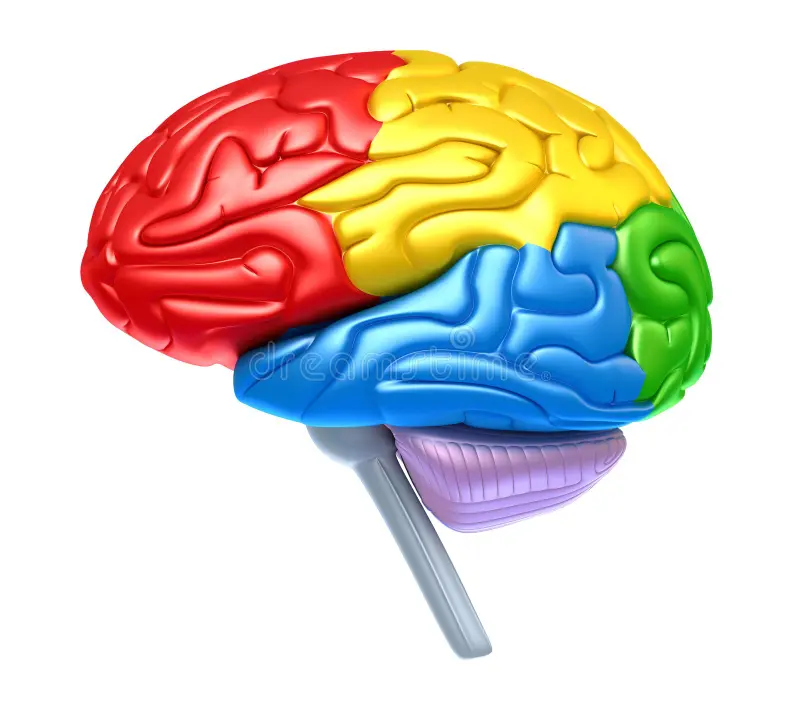

In [9]:
recovered_brain

In [10]:
# A matrix that scrambles RGB
M = np.array([[0.5, 0.8, 0.2],
              [0.1, 0.3, 0.9],
              [0.7, 0.2, 0.1]])

# Apply it only to the extracted brain pixels
# Flattened pixels for matrix multiplication: (N_pixels, 3)
#aligning dimentions
pixels = extracted_brain[mask].astype(float)
scrambled_pixels = pixels @ M.T

# Put them back and clip to 0-255
scrambled_brain[mask] = np.clip(scrambled_pixels, 0, 255).astype('uint8')

In [11]:
import numpy as np

# Your scramble matrix
M = np.array([[0.5, 0.8, 0.2],
              [0.1, 0.3, 0.9],
              [0.7, 0.2, 0.1]])

# Calculate eigenvalues (w) and eigenvectors (v)
eigenvalues, eigenvectors = np.linalg.eig(M)

# Find the index of the largest (dominant) eigenvalue
idx = np.argmax(np.abs(eigenvalues))
dominant_eigenvector = eigenvectors[:, idx].real

# Normalize to 0-255 to see it as a color
# We use abs because color values can't be negative
eigen_color = np.abs(dominant_eigenvector)
eigen_color = (eigen_color / np.max(eigen_color) * 255).astype(np.uint8)

print(f"The 'Steady State' Color (R,G,B): {eigen_color}")

The 'Steady State' Color (R,G,B): [255 199 186]


In [12]:

# 1. Assuming you have already calculated 'eigen_color'
eigen_color = [255, 199, 186]

# 2. Define the size of your preview patch (100x100 pixels)
patch_size = (100, 100)

# 3. Create a numpy array filled with this color
# We create an array of shape (Height, Width, 3) and initialize with zeros
eigen_patch = np.zeros((*patch_size, 3), dtype=np.uint8)

# 4. Fill the entire patch with the eigen color
eigen_patch[:] = eigen_color

In [13]:
# 5. Convert the array to a PIL Image object
preview_image = Image.fromarray(eigen_patch)

# 6. Display it in the notebook output
print(f"Previewing the 'Steady State' Eigen-Color: {eigen_color}")
# In Colab, just typing the variable name displays the image:
# preview_image

Previewing the 'Steady State' Eigen-Color: [255, 199, 186]


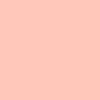

In [14]:
preview_image

In [15]:
# 1. Decompose the matrix M
U, S, Vh = np.linalg.svd(M)

# S contains the Singular Values (ordered from largest to smallest)
# Vh[0] is the First Right Singular Vector (The "Most Affected" direction)

print(f"Singular Values: {S}")

# Normalize the first singular vector to see it as an RGB color
v1_color = np.abs(Vh[0])
v1_color = (v1_color / np.max(v1_color) * 255).astype(np.uint8)

print(f"The 'Direction of Greatest Change' (RGB): {v1_color}")

Singular Values: [1.28599669 0.75553003 0.39419144]
The 'Direction of Greatest Change' (RGB): [223 255 217]


Singular Values: Sigma1=1.29, Sigma2=0.76, Sigma3=0.39


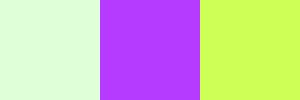

In [17]:

# 1. Assuming U, S, Vh = np.linalg.svd(M) has been run
# We take the rows of Vh (the Right Singular Vectors)
singular_vectors = Vh

patches = []
for i in range(3):
    # Get the vector and normalize for display
    vec = np.abs(singular_vectors[i])
    color = (vec / np.max(vec) * 255).astype(np.uint8)

    # Create a 100x100 patch for this singular direction
    patch = np.zeros((100, 100, 3), dtype=np.uint8)
    patch[:] = color
    patches.append(patch)

# Combine them side-by-side: [v1] [v2] [v3]
palette = np.hstack(patches)
preview_palette = Image.fromarray(palette)
print(f"Singular Values: Sigma1={S[0]:.2f}, Sigma2={S[1]:.2f}, Sigma3={S[2]:.2f}")

preview_palette

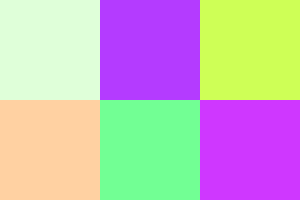

In [18]:
# Create a 2-row palette
# Row 1: Right Singular Vectors (The "Target" colors in the original brain)
# Row 2: Left Singular Vectors (The "Resulting" colors after scramble)

row_v = [] # Targets
row_u = [] # Results

for i in range(3):
    # Normalize Vh[i] (Targets)
    c_v = np.abs(Vh[i])
    c_v = (c_v / np.max(c_v) * 255).astype(np.uint8)
    patch_v = np.zeros((100, 100, 3), dtype=np.uint8)
    patch_v[:] = c_v
    row_v.append(patch_v)

    # Normalize U[:, i] (Results)
    c_u = np.abs(U[:, i])
    c_u = (c_u / np.max(c_u) * 255).astype(np.uint8)
    patch_u = np.zeros((100, 100, 3), dtype=np.uint8)
    patch_u[:] = c_u
    row_u.append(patch_u)

# Stack them into a 2-row grid
top_row = np.hstack(row_v)
bottom_row = np.hstack(row_u)
full_grid = np.vstack([top_row, bottom_row])

Image.fromarray(full_grid)

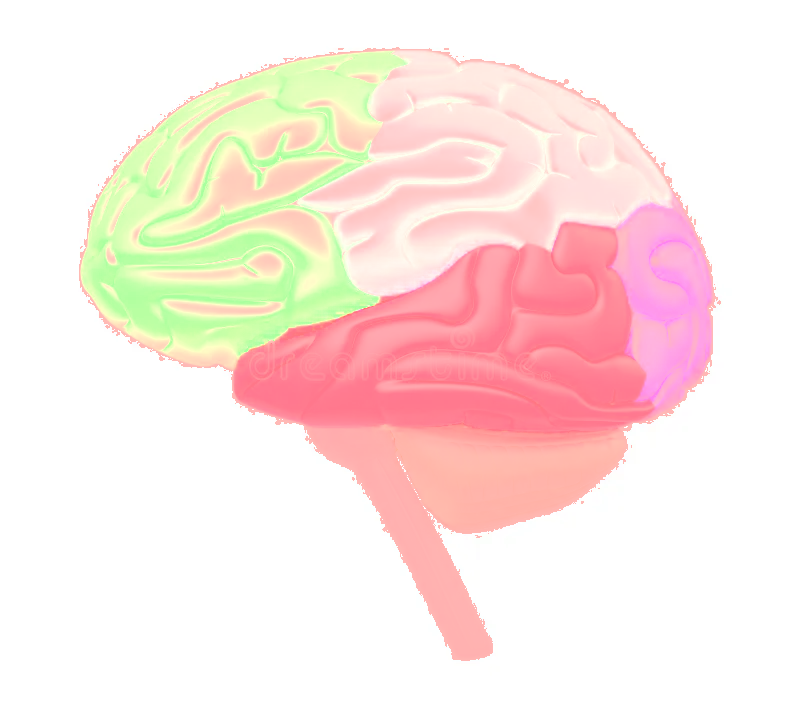

In [25]:
# 1. Setup
current_brain = data.copy().astype(float)
mask = np.any(data < 250, axis=-1) # Focus only on the brain

# 2. The 10-Step Scramble
for i in range(2):
    # Get the brain pixels
    pixels = current_brain[mask]

    # Apply the transformation (The "Mint Green" Hunter)
    # Using the Transpose M.T for the (N, 3) @ (3, 3) handshake
    transformed = pixels @ M.T

    # Normalization: Keep the brightness stable so it doesn't wash out
    # We scale each pixel so its maximum channel is 255
    max_vals = transformed.max(axis=1, keepdims=True)
    max_vals[max_vals == 0] = 1 # Avoid division by zero
    normalized = (transformed / max_vals) * 255

    # Put them back into the image
    current_brain[mask] = normalized

# 3. Final Render
final_scramble = current_brain.astype(np.uint8)
Image.fromarray(final_scramble)

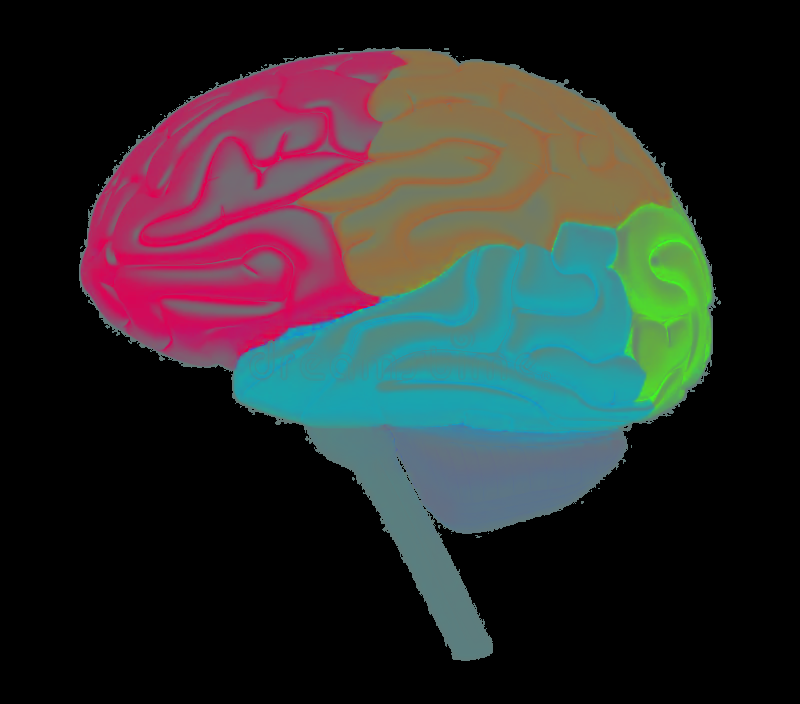

In [20]:
# 1. Get the SVD of the SCRAMBLED pixels (the final 10th iteration)
U_scr, S_scr, Vh_scr = np.linalg.svd(current_brain[mask], full_matrices=False)

# 2. Reconstruct ONLY the first (dominant) component
# This is the "Pink Veil" that covered everything
first_component = (U_scr[:, 0:1] * S_scr[0]) @ Vh_scr[0:1, :]

# 3. SUBTRACT it from the scrambled pixels
# This leaves behind the 'Residuals' (the detail the matrix ignored)
residual_pixels = current_brain[mask] - first_component

# 4. Normalize and Clip for display
# Since subtraction creates negatives, we shift or scale to see the contrast
residual_pixels = residual_pixels - residual_pixels.min()
residual_pixels = (residual_pixels / residual_pixels.max() * 255).astype(np.uint8)

# 5. Put it back and display
residual_brain = np.zeros_like(data)
residual_brain[mask] = residual_pixels
Image.fromarray(residual_brain)

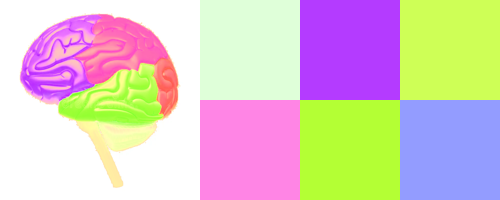

In [29]:
import numpy as np
from PIL import Image

# 1. Setup Data and SVD
# Assuming 'data' is your original (H, W, 3) brain and 'M' is your matrix
current_brain = data.copy().astype(float)
mask = np.any(data < 250, axis=-1)
U, S, Vh = np.linalg.svd(M)

def create_visual_step(image_array):
    # --- Part A: The Brain (Resize to 200x200) ---
    brain_display = Image.fromarray(image_array.astype(np.uint8)).resize((200, 200))
    brain_np = np.array(brain_display)

    # --- Part B: The SVD Palette (2 rows of 100px = 200px height) ---
    rows = []
    # Row 1: Right Singular Vectors (Targets V)
    # Row 2: Left Singular Vectors (Results U)
    for vecs, is_u in [(Vh, False), (U.T, True)]:
        patches = []
        for j in range(3):
            # Extract and normalize color
            vec = np.abs(vecs[:, j]) if is_u else np.abs(vecs[j])
            color = (vec / np.max(vec) * 255).astype(np.uint8)

            # Create 100x100 patch
            patch = np.zeros((100, 100, 3), dtype=np.uint8)
            patch[:] = color
            patches.append(patch)
        rows.append(np.hstack(patches)) # This row is 100x300

    palette_np = np.vstack(rows) # This is 200x300

    # --- Part C: The Handshake (Stitch 200px height to 200px height) ---
    combined = np.hstack([brain_np, palette_np])
    return Image.fromarray(combined)

# 2. Run the Transformation (Iteration 1)
pixels = current_brain[mask]
transformed = pixels @ M.T

# Normalize to keep the "Pink" visible and stable
max_vals = transformed.max(axis=1, keepdims=True)
max_vals[max_vals == 0] = 1
current_brain[mask] = (transformed / max_vals) * 255

# 3. Display Result
# Top Row of Palette = What the matrix hunts (Mint Green)
# Bottom Row of Palette = What the matrix makes (Salmon Pink)
full_visual = create_visual_step(current_brain)
full_visual

Iteration 0 (Start)  ->  Iteration 1 (Green Death)  ->  ...  ->  Iteration 5 (Steady State)


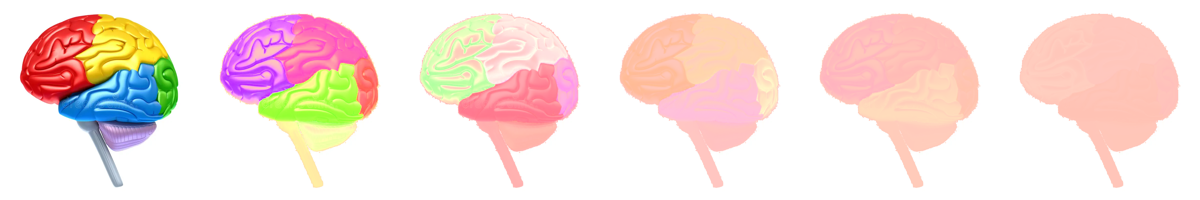

In [31]:
import numpy as np
from PIL import Image

# 1. Setup
current_brain = data.copy().astype(float)
mask = np.any(data < 250, axis=-1)
history_images = []

# Add the "Initial State" (Iteration 0)
history_images.append(Image.fromarray(data).resize((200, 200)))

# 2. Run 5 Iterations
for i in range(1, 6):
    # Transform pixels
    pixels = current_brain[mask]
    transformed = pixels @ M.T

    # Normalize brightness to keep the Salmon Pink from washing out
    max_vals = transformed.max(axis=1, keepdims=True)
    max_vals[max_vals == 0] = 1
    current_brain[mask] = (transformed / max_vals) * 255

    # Capture the state
    step_img = Image.fromarray(current_brain.astype(np.uint8)).resize((200, 200))
    history_images.append(step_img)

# 3. Create a Horizontal Filmstrip
# This stitches Iteration 0, 1, 2, 3, 4, 5 side-by-side
filmstrip = np.hstack([np.array(img) for img in history_images])
final_view = Image.fromarray(filmstrip)

print("Iteration 0 (Start)  ->  Iteration 1 (Green Death)  ->  ...  ->  Iteration 5 (Steady State)")
final_view

In [35]:
from manim import *
import numpy as np
from PIL import Image

class BrainScramble(Scene):
    def construct(self):
        # 1. Load and Prepare Data
        # Replace 'brain_image.png' with your actual file path
        original_img = Image.open('brain_lobes.png').convert('RGB')
        pixel_array = np.array(original_img).astype(float)
        mask = np.any(pixel_array < 250, axis=-1)  # Focus on the brain, ignore white bg

        # Define your Scramble Matrix M
        M = np.array([[0.5, 0.8, 0.2],
                      [0.1, 0.3, 0.9],
                      [0.7, 0.2, 0.1]])

        # Create the Manim ImageMobject
        brain_mobject = ImageMobject(pixel_array.astype(np.uint8))
        brain_mobject.scale(2)
        self.add(brain_mobject)

        # 2. Iteration Counter UI
        counter = Integer(0).to_edge(UP + RIGHT)
        label = Text("Iteration:").next_to(counter, LEFT)
        self.add(label, counter)

        # 3. The Animation Loop (5 Iterations)
        for i in range(1, 6):
            # --- The Math Step ---
            pixels = pixel_array[mask]
            transformed = pixels @ M.T

            # Normalize to keep colors within [0, 255] and prevent washout
            max_vals = transformed.max(axis=1, keepdims=True)
            max_vals[max_vals == 0] = 1
            pixel_array[mask] = (transformed / max_vals) * 255

            # --- The Animation Step ---
            # Create a new ImageMobject for the next state
            new_brain = ImageMobject(pixel_array.astype(np.uint8))
            new_brain.replace(brain_mobject)

            # Animate the transition
            self.play(
                Transform(brain_mobject, new_brain),
                counter.animate.set_value(i),
                run_time=1,
                rate_func=smooth
            )
            self.wait(0.5)

        # 4. Final Hold
        self.wait(2)

In [36]:
%%manim -v WARNING -qm BrainScramble

Manim Community v0.20.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')